In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/home/vivek/Desktop/healthcare_dataset.csv.zip",compression="zip")
print(df)
df.head(10)

                    Name  Age  Gender Blood Type Medical Condition  \
0          Bobby JacksOn   30    Male         B-            Cancer   
1           LesLie TErRy   62    Male         A+           Obesity   
2            DaNnY sMitH   76  Female         A-           Obesity   
3           andrEw waTtS   28  Female         O+          Diabetes   
4          adrIENNE bEll   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
55495  eLIZABeTH jaCkSOn   42  Female         O+            Asthma   
55496         KYle pEREz   61  Female        AB-           Obesity   
55497       HEATher WaNG   38  Female         B+      Hypertension   
55498     JENniFER JOneS   43    Male         O-         Arthritis   
55499       jAMES GARCiA   53  Female         O+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            2024-01-31     Matthew Smith               Sons and Miller   
1        

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [87]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [88]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [89]:
df.drop_duplicates(inplace=True)

In [90]:
df.describe()

,Age,Billing Amount,Room Number
count,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306284,301.124404
std,19.605661,14208.409711,115.223143
min,13.000000,-2008.492140,101.000000
25%,35.000000,13243.718641,202.000000
50%,52.000000,25542.749145,302.000000
75%,68.000000,37819.858159,401.000000
max,89.000000,52764.276736,500.000000


1. Which medical condition has the highest average billing amount?

In [91]:
avg_billing=df.groupby('Medical Condition')['Billing Amount'].mean()
print(avg_billing)

Medical Condition
Arthritis       25511.783246
Asthma          25633.461696
Cancer          25152.322947
Diabetes        25660.478635
Hypertension    25503.058720
Obesity         25804.361902
Name: Billing Amount, dtype: float64


/tmp/ipykernel_2929/185842168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_billing,palette="coolwarm")


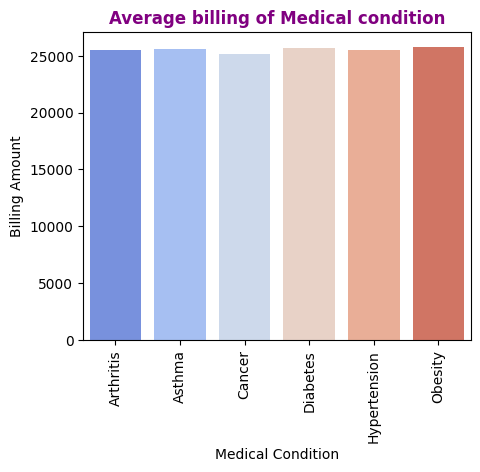

In [92]:
plt.figure(figsize=(5,4))
sns.barplot(data=avg_billing,palette="coolwarm")
plt.title("Average billing of Medical condition",fontweight="bold",color="Purple")
plt.xticks(rotation=90)
plt.show()

2. which insurance provider has the highest total billing amount ?

In [93]:
highest=df.groupby("Insurance Provider")['Billing Amount'].sum().sort_values(ascending=False)
print(highest)

Insurance Provider
Cigna               2.843341e+08
Medicare            2.829110e+08
Blue Cross          2.804091e+08
UnitedHealthcare    2.799154e+08
Aetna               2.764987e+08
Name: Billing Amount, dtype: float64


/tmp/ipykernel_2929/2320885715.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=highest,palette="rocket_r")


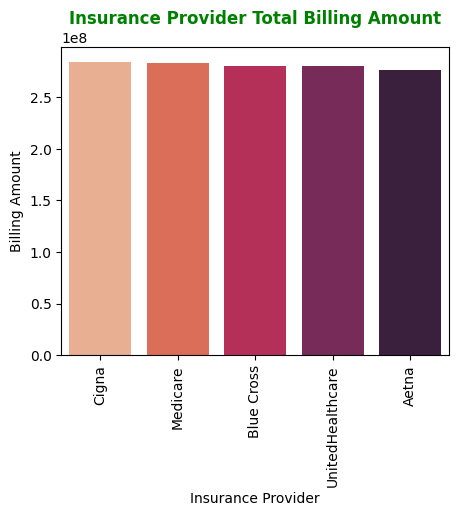

In [94]:
plt.figure(figsize=(5,4))
sns.barplot(data=highest,palette="rocket_r")
plt.title("Insurance Provider Total Billing Amount",fontweight="bold",color="green")
plt.xticks(rotation=90)
plt.show()

3. What is average length of hospital stay for each admission type?

In [95]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Stay Duration'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

avg = df.groupby('Admission Type')['Stay Duration'].mean().reset_index(name="avg_days")

print(avg)

  Admission Type   avg_days
0       Elective  15.511178
1      Emergency  15.584134
2         Urgent  15.403839


/tmp/ipykernel_2929/1794474436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg,x='Admission Type',y='avg_days',palette="mako")


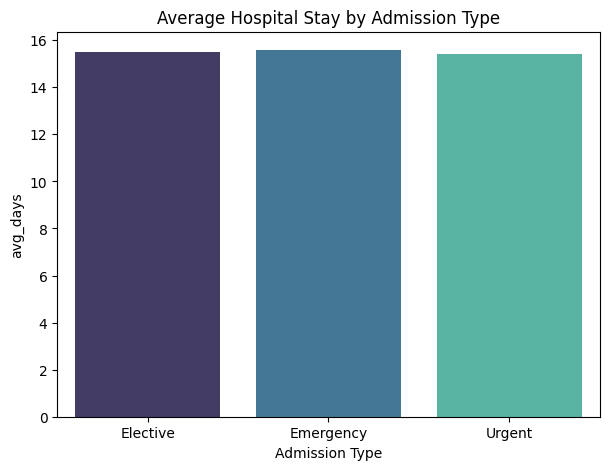

In [96]:
plt.figure(figsize=(7,5))

sns.barplot(data=avg,x='Admission Type',y='avg_days',palette="mako")

plt.title("Average Hospital Stay by Admission Type")

plt.show()

4. Which hospital treated the highest number of patients?

In [97]:
treated=df.groupby('Hospital').size().sort_values(ascending=False).head(20)
print(treated)

Hospital
LLC Smith        44
Ltd Smith        39
Smith Ltd        37
Johnson PLC      37
Smith PLC        36
Smith Group      36
Johnson Inc      34
Smith Inc        33
Group Smith      32
Smith LLC        32
LLC Johnson      30
PLC Williams     30
PLC Smith        29
Brown Inc        28
Inc Brown        27
Inc Smith        27
Johnson Group    27
Group Johnson    26
Inc Johnson      26
Inc Jones        25
dtype: int64


/tmp/ipykernel_2929/704890287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=treated,palette="muted")


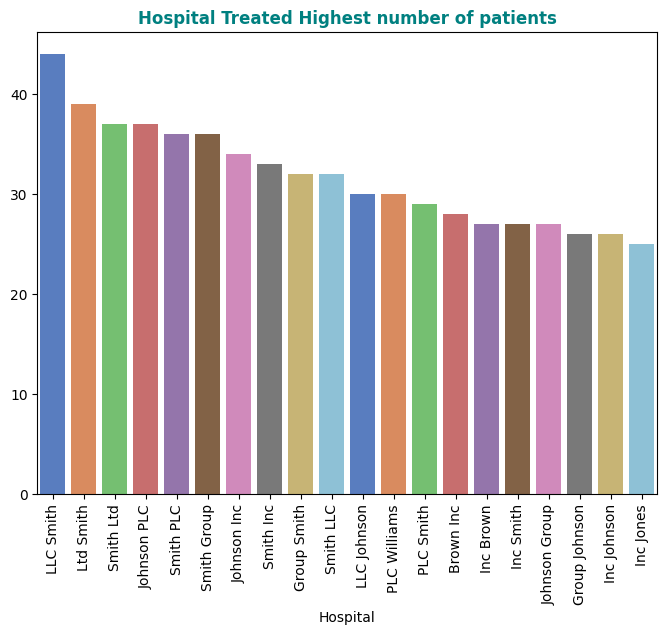

In [98]:
plt.figure(figsize=(8,6))
sns.barplot(data=treated,palette="muted")
plt.title("Hospital Treated Highest number of patients",fontweight="bold",color="Teal")
plt.xticks(rotation=90)
plt.show()

5. which age group contributes the highest total billing?

In [99]:
# Age Group create 
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 20, 40, 60, float('inf')],labels=['0-20', '21-40', '41-60', '60+'])

#  total billing
billing_by_age = df.groupby('Age Group')['Billing Amount'].sum()

print(billing_by_age)


Age Group
0-20     6.285909e+07
21-40    4.103306e+08
41-60    4.168568e+08
60+      5.140219e+08
Name: Billing Amount, dtype: float64


/tmp/ipykernel_2929/1110819275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(data=billing_by_age,palette="coolwarm")


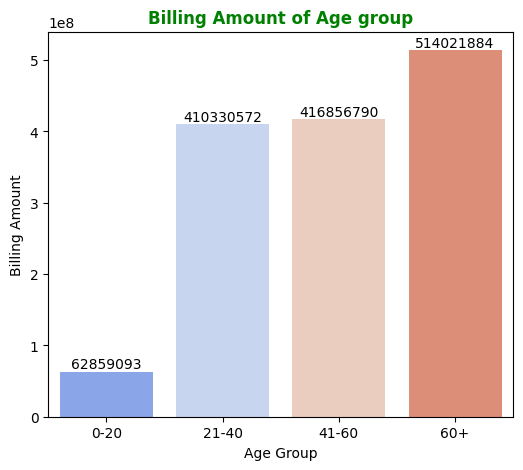

In [100]:
plt.figure(figsize=(6,5))
ax= sns.barplot(data=billing_by_age,palette="coolwarm")
plt.title("Billing Amount of Age group",fontweight="bold",color="Green")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f') 

plt.show()

In [101]:
highest_revenue=df.groupby('Doctor')['Billing Amount'].sum().sort_values(ascending=False).head(10)
print(highest_revenue)

Doctor
Michael Smith      784501.843132
John Smith         610109.604175
Robert Smith       609160.688766
Robert Johnson     524193.003178
David Smith        473345.609187
William Johnson    469198.116030
John Johnson       466769.966463
James Smith        461817.900317
Michael Johnson    460819.038528
David Johnson      445605.542275
Name: Billing Amount, dtype: float64


/tmp/ipykernel_2929/2927490611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=highest_revenue,palette="seismic")


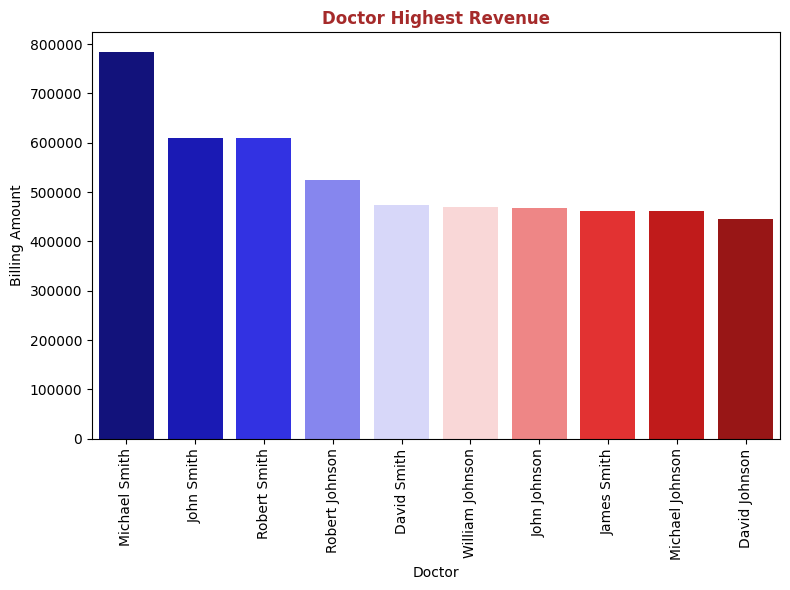

In [102]:
plt.figure(figsize=(8,6))
sns.barplot(data=highest_revenue,palette="seismic")
plt.title("Doctor Highest Revenue",fontweight="bold",color="brown")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

7. What percentage of patients have normal.abnormal,and inconslusive tests results?

In [103]:
percentage=df['Test Results'].value_counts()
print(percentage)

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64


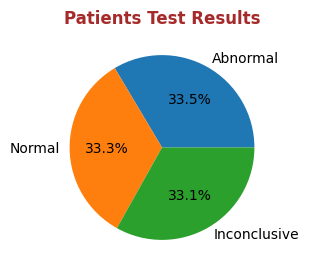

In [104]:
plt.figure(figsize=(5,3))
plt.pie(x=percentage.values,labels=percentage.index,autopct='%1.1f%%')
plt.title("Patients Test Results",fontweight="bold",color="Brown")
plt.show()

8. which medical condition has the longest average hospital stay?

In [105]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Stay Duration'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

avg_stay = df.groupby('Medical Condition')['Stay Duration'].mean()

print(avg_stay)

Medical Condition
Arthritis       15.504231
Asthma          15.677295
Cancer          15.501204
Diabetes        15.430664
Hypertension    15.436236
Obesity         15.447627
Name: Stay Duration, dtype: float64


/tmp/ipykernel_2929/1968436218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


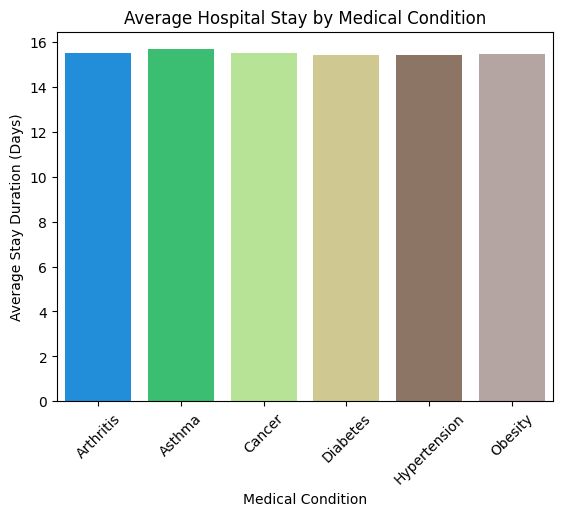

In [106]:
avg_stay = avg_stay.reset_index()

sns.barplot(
    data=avg_stay,
    x='Medical Condition',
    y='Stay Duration',
    palette="terrain"
)

plt.title("Average Hospital Stay by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Stay Duration (Days)")

plt.xticks(rotation=45)
plt.show()

9. Which medication is prescribed most frequently for each medical condition?

In [107]:
description = df.groupby(['Medical Condition','Medication']).size().reset_index(name='Count')

result = description.loc[
    description.groupby('Medical Condition')['Count'].idxmax()
]

print(result)

   Medical Condition   Medication  Count
0          Arthritis      Aspirin   1901
8             Asthma  Paracetamol   1870
12            Cancer      Lipitor   1904
17          Diabetes      Lipitor   1875
21      Hypertension    Ibuprofen   1874
29           Obesity   Penicillin   1872


/tmp/ipykernel_2929/2277608099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


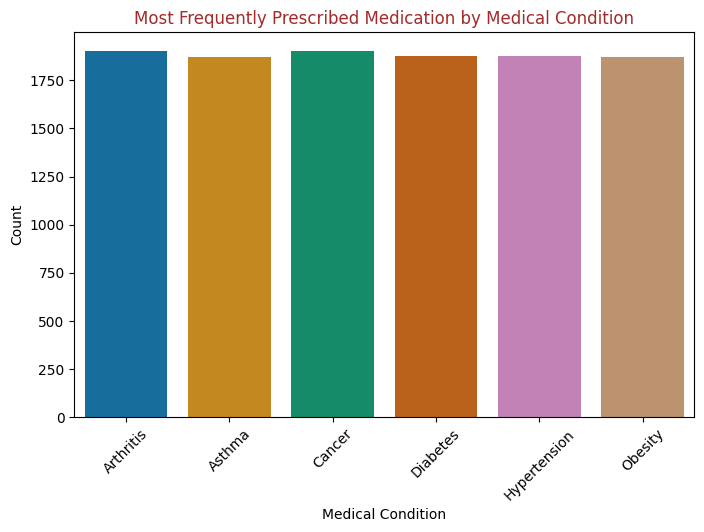

In [108]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=result,
    x='Medical Condition',
    y='Count',
    palette="colorblind"
)

plt.title("Most Frequently Prescribed Medication by Medical Condition",color="Brown")
plt.xticks(rotation=45)
plt.show()

10. Identify the top 10 pateints with the highst billing amounts and analyze their common characterstics?

In [109]:
top10=df[['Name','Billing Amount','Age','Insurance Provider']].sort_values(by='Billing Amount',ascending=False).head(10)
print(top10)


                   Name  Billing Amount  Age Insurance Provider
36349     tOdd CARrILlO    52764.276736   51         Blue Cross
34613       kARen klInE    52373.032374   79   UnitedHealthcare
51313       kARen klInE    52373.032374   74   UnitedHealthcare
5735     DAVId SanDOvaL    52271.663747   22         Blue Cross
7088   kathRYN GoNzales    52211.852966   18              Aetna
1574     BRETT mARshAll    52181.837792   42              Aetna
6663        LAuRie hOod    52170.036854   42              Cigna
52826       LAuRie hOod    52170.036854   43              Cigna
33117      JUstIn CLark    52154.237722   53   UnitedHealthcare
34368      sCotT pOWElL    52102.240889   38              Cigna


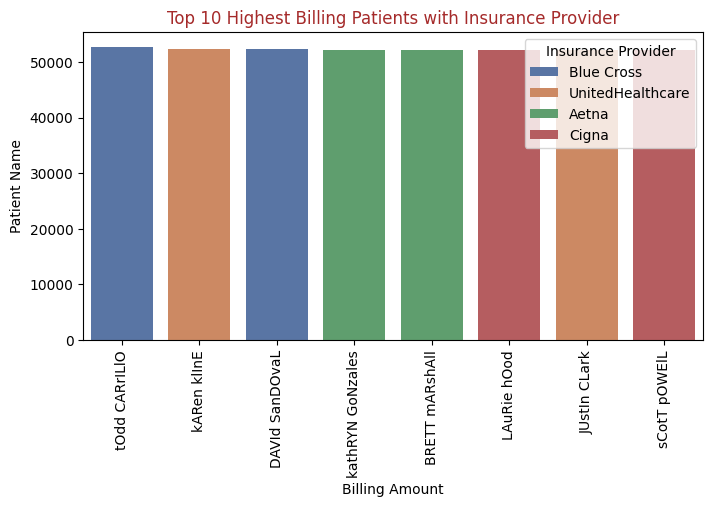

In [110]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=top10,
    y='Billing Amount',
    x='Name',
    hue='Insurance Provider',
    palette="deep"
)

plt.title("Top 10 Highest Billing Patients with Insurance Provider",color="Brown")
plt.xlabel("Billing Amount")
plt.ylabel("Patient Name")
plt.xticks(rotation=90)
plt.show()